In [8]:
# data handling libraries
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# model save करने के लिए
import pickle

In [9]:
# Bengaluru house dataset load
data = pd.read_csv("Bengaluru_House_Data.csv")

# dataset की पहली 5 rows
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [10]:
# dataset structure check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [11]:
# missing values count
data.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [12]:
# society column remove क्योंकि इसमें बहुत missing values हैं
data = data.drop("society", axis=1)

In [13]:
# location missing row remove
data = data.dropna(subset=["location"])

In [15]:
# size column में missing rows remove
data = data.dropna(subset=["size"])

# size column से bhk number निकालना
data["bhk"] = data["size"].apply(lambda x: int(str(x).split()[0]))

In [16]:
# size column में missing rows remove
data = data.dropna(subset=["size"])

# size column से bhk number निकालना
data["bhk"] = data["size"].apply(lambda x: int(str(x).split()[0]))

In [17]:
# total_sqft clean करने का function
def convert_sqft(x):
    
    tokens = str(x).split('-')
    
    # अगर range है तो average निकालेंगे
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    
    try:
        return float(x)
    except:
        return None

In [18]:
# function apply
data["total_sqft"] = data["total_sqft"].apply(convert_sqft)

In [19]:
# bath column की missing values median से fill
data["bath"] = data["bath"].fillna(data["bath"].median())

In [20]:
# balcony missing values fill
data["balcony"] = data["balcony"].fillna(data["balcony"].median())

In [26]:
# बाकी missing rows remove
data = data.dropna()

In [27]:
# input features
X = data.drop("price", axis=1)

# target variable
y = data["price"]

In [28]:
# categorical columns encode
X = pd.get_dummies(X)

In [29]:
# dataset split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

# scaler object
scaler = StandardScaler()

# training data scale
X_train = scaler.fit_transform(X_train)

# testing data scale
X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import Ridge

# ridge model create
ridge = Ridge(alpha=1.0)

# model training
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [32]:
# prediction
ridge_pred = ridge.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))
print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge MSE: 10845.321274037284
Ridge R2: 0.503632227439526


In [34]:
from sklearn.linear_model import Lasso

# lasso model create
lasso = Lasso(alpha=0.1)

# model training
lasso.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [35]:
# prediction
lasso_pred = lasso.predict(X_test)

In [36]:
print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso MSE: 10760.698308510184
Lasso R2: 0.5075052443695733


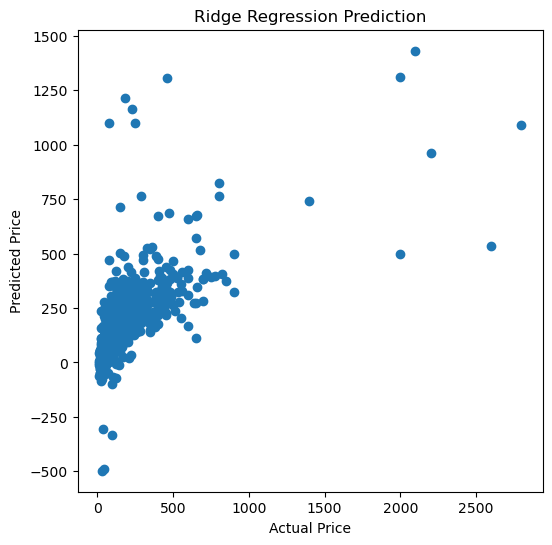

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression Prediction")
plt.show()

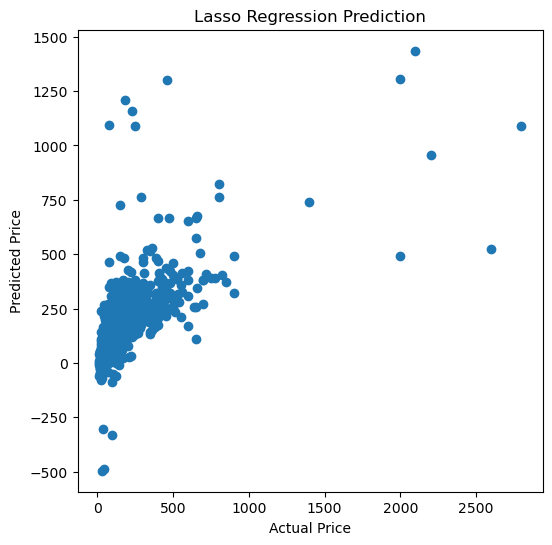

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lasso_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression Prediction")
plt.show()

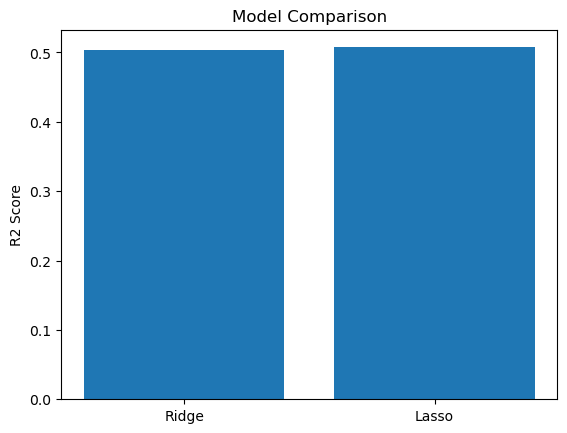

In [39]:
models = ["Ridge","Lasso"]
scores = [
    r2_score(y_test, ridge_pred),
    r2_score(y_test, lasso_pred)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

In [40]:
import pickle

pickle.dump(ridge, open("ridge_model.pkl","wb"))
pickle.dump(lasso, open("lasso_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))